In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer

In [4]:
df = pd.read_csv('used_car_listings.csv',usecols=[9,10,11])

In [5]:
df.head()

,mileage,price,condition
0,46134,19919.0,good
1,16109,19480.0,good
2,173239,4556.0,good
3,36810,11536.0,fair
4,87749,14098.0,good


In [8]:
df.isnull().sum()

mileage      0
price        0
condition    0
dtype: int64

In [7]:
df['condition'].fillna(df['condition'].value_counts().index[0],inplace=True)

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_7736\2052693466.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['condition'].fillna(df['condition'].value_counts().index[0],inplace=True)


In [9]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.head()

,mileage,price
932,108268,5430.0
1523,274780,1208.0
1111,0,28595.0
1679,95435,7609.0
123,77534,3971.0


In [10]:
# label Encoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_transformed = le.fit_transform(y_train)
y_test_transformed = le.fit_transform(y_test)

y_transformed = le.fit_transform(y)

y_train_transformed = pd.DataFrame(y_train_transformed)
y_train_transformed.value_counts()

0
2    684
0    476
1    301
3     82
5     77
4     34
Name: count, dtype: int64

In [11]:
# Model Before Transfomration

In [12]:
clf = LogisticRegression()

clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)

accuracy_score(y_test,y_pred)

E:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.42995169082125606

In [13]:

np.mean(cross_val_score(clf,x, y, scoring="accuracy"))

E:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
E:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_resu

0.4168275023101847

In [14]:
trf = ColumnTransformer([
    ('first',KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform'),[0]),
    ('second',KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform'),[1])
])

x_train_trf = trf.fit_transform(x_train)
x_test_trf = trf.transform(x_test)

In [16]:
output = pd.DataFrame({
    'mileage':x_train['mileage'],
    'mileage_trf':x_train_trf[:,0],
    'price':x_train['price'],
    'price_trf':x_train_trf[:,1]
})

In [18]:
output['mileage_labels'] = pd.cut(x=x_train['mileage'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['price_labels'] = pd.cut(x=x_train['price'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())



In [19]:
output.sample(4)

,mileage,mileage_trf,price,price_trf,mileage_labels,price_labels
149,27643,0.0,18768.0,2.0,"(0.0, 41842.8]","(15440.2, 22590.3]"
917,53337,1.0,5323.0,0.0,"(41842.8, 83685.6]","(1140.0, 8290.1]"
892,64830,1.0,7296.0,0.0,"(41842.8, 83685.6]","(1140.0, 8290.1]"
68,106385,2.0,2147.0,0.0,"(83685.6, 125528.4]","(1140.0, 8290.1]"


In [20]:
# Model after Transformation

In [21]:
clf = LogisticRegression()

clf.fit(x_train_trf, y_train)

y_pred2 = clf.predict(x_test_trf)

accuracy_score(y_test,y_pred2)

0.42995169082125606

In [22]:
x_transform = trf.transform(x)
np.mean(cross_val_score(clf,x_transform,y,scoring="accuracy",cv=10))

0.4187467754795741

In [23]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    x_trf = trf.fit_transform(x)
    print(np.mean(cross_val_score(clf,x_trf,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['mileage'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(x_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['price'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(x_trf[:,1],color='red')
    plt.title("after")
    

0.4187467754795741


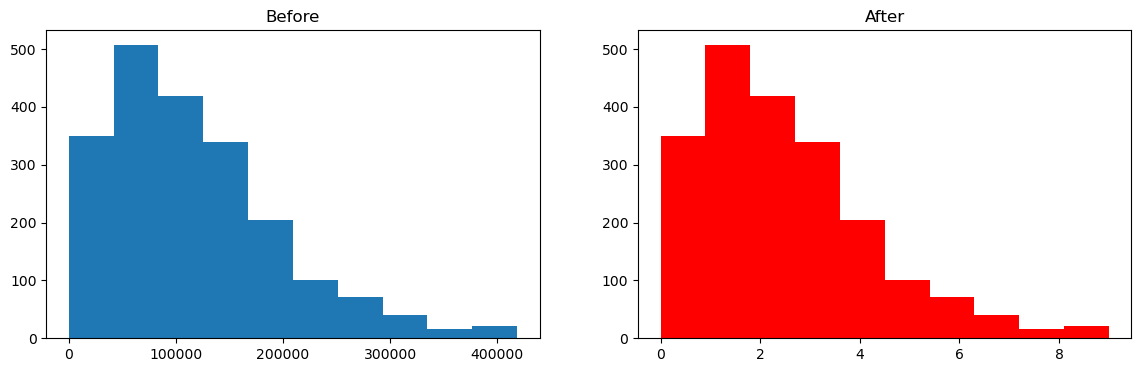

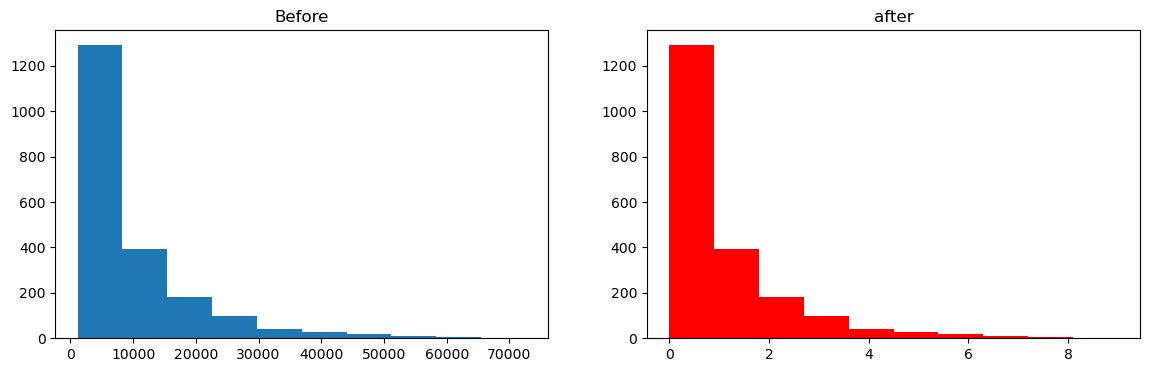

In [26]:
discretize(10,"uniform")

E:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
E:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_resu

0.41537920360208247


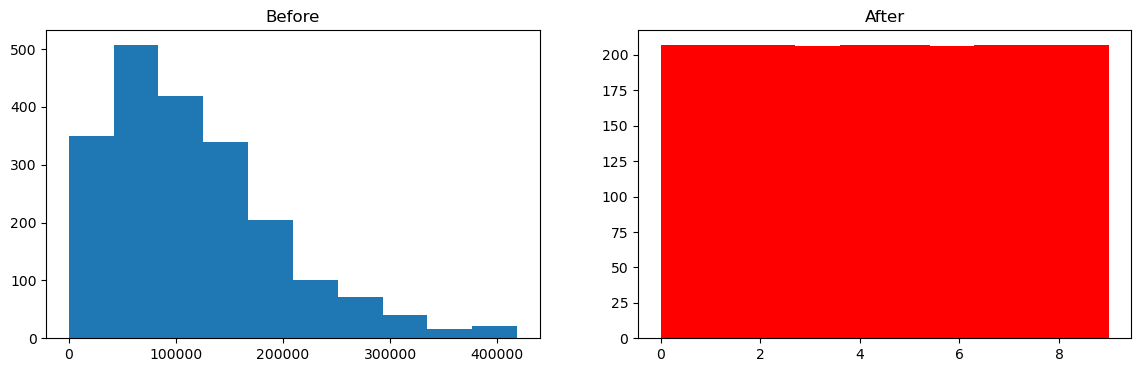

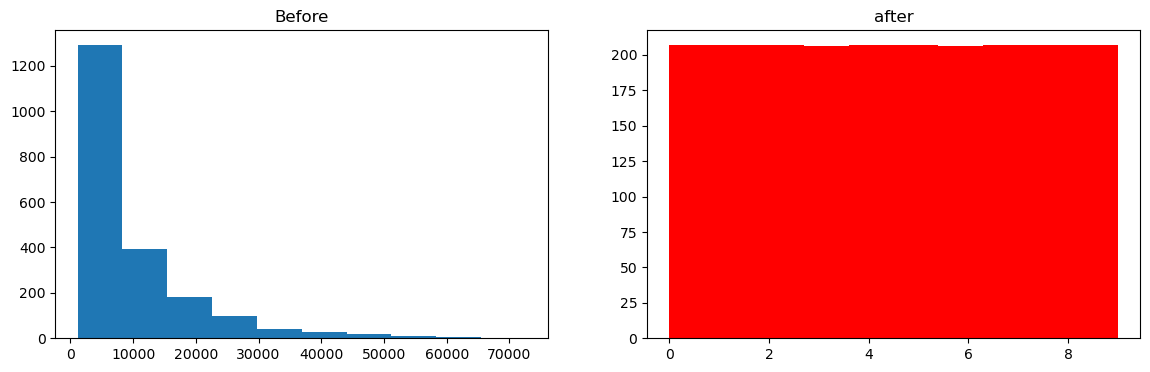

In [27]:
discretize(10,"quantile")

0.4168120632240514


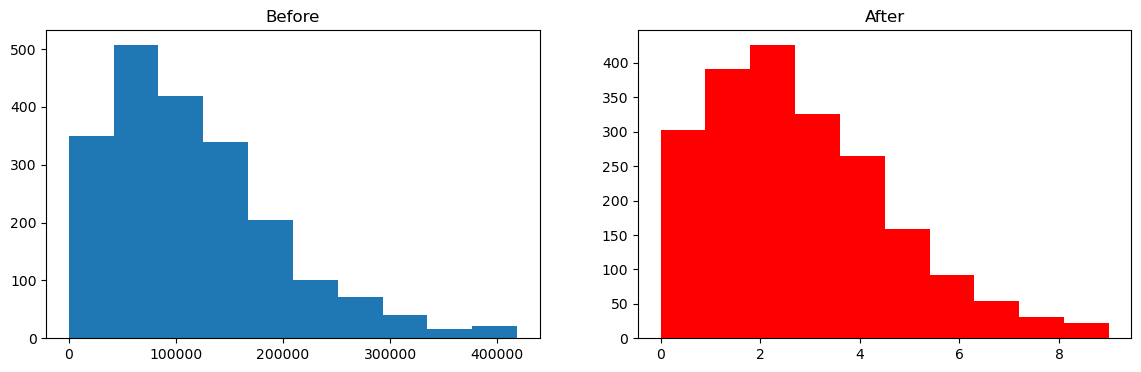

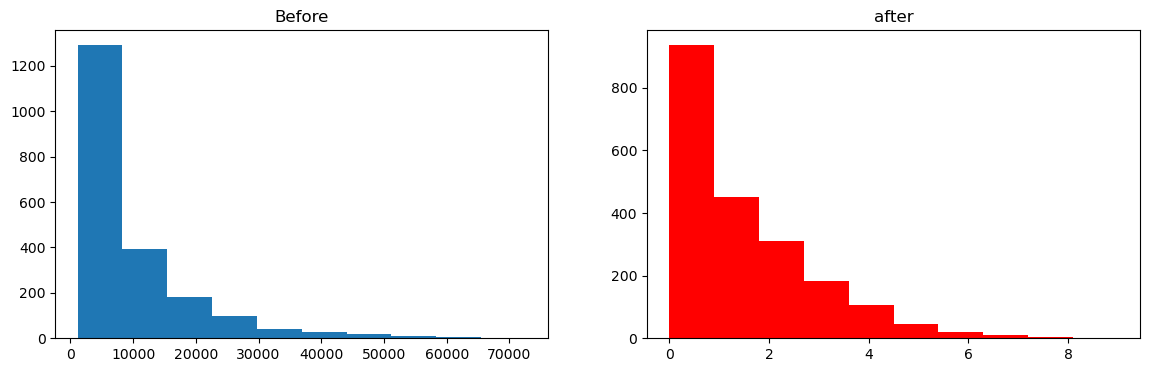

In [28]:
discretize(10,"kmeans")